In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
#Load data
df = pd.read_csv("/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [ ]:
#Basic Inspection
print(df.head())
print(df.info())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [ ]:
#Encode categorical columns
Category_cols = df.select_dtypes(include=['object']).columns #identifying

In [ ]:
#Encode attrition separatly as target
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [ ]:
#Encode others
le = LabelEncoder()
for col in Category_cols:
  if col != 'Attrition':
    df[col] = le.fit_transform(df[col])


In [ ]:
#Split features & target
x = df.drop('Attrition', axis=1)
y = df['Attrition']

In [ ]:
#Scale features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [ ]:
#train or test and split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [ ]:
# model training
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(x_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
#Predictions
y_pred = model.predict(x_test)

In [ ]:
#evalution
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nonfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8741496598639455

onfusion Matrix:
 [[253   2]
 [ 35   4]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.67      0.10      0.18        39

    accuracy                           0.87       294
   macro avg       0.77      0.55      0.55       294
weighted avg       0.85      0.87      0.83       294



In [ ]:
# Visualization
feature_importances = pd.Series(model.feature_importances_, index=df.drop('Attrition', axis=1).columns)
top_features = feature_importances.nlargest(10)

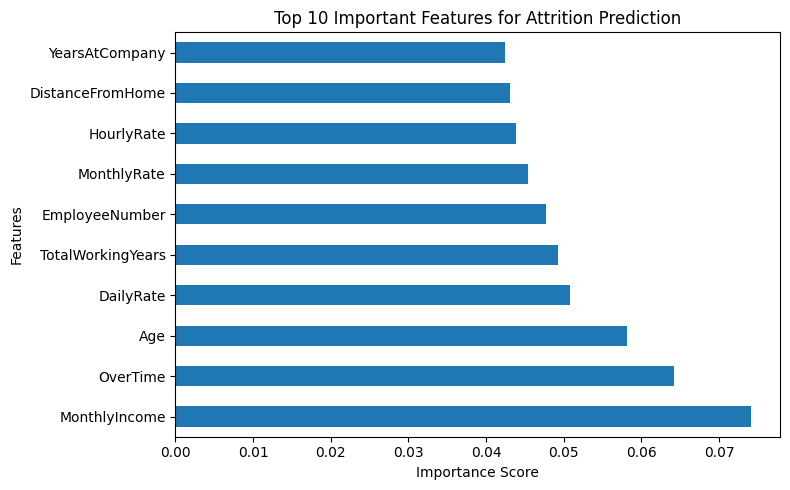

In [ ]:
plt.figure(figsize=(8,5))
top_features.plot(kind='barh')
plt.title('Top 10 Important Features for Attrition Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()
